**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [2]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
# df = ...

# Task 2: Inspect the data
# TODO: Display the first 5 rows of the dataset
# ...

# TODO: Display the last 5 rows of the dataset
# ...

# TODO: Display the data types of each column
# ...

# TODO: Display summary statistics of the numerical columns
# ...

# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
# df['PclassCategory'] = ...

# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
# df['CabinCategory'] = ...

# TODO: Handle missing values in the 'Age' column (use mean age)
# ...

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'
# df['Family'] = ...

# Task 4: Identify specific data points

# TODO: Find passengers with the highest fare
# highest_fare_passengers = ...

# TODO: Find passengers with the largest family size
# largest_family_passengers = ...

# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# TODO: Create a Pandas Series of passenger names
# names_series = ...

# TODO: Create a DataFrame of passenger names and ages
# names_ages_df = ...

# TODO: Slice the DataFrame to show only passengers older than 50
# older_passengers = ...

# Task 6: Introduce multi-indexing

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
# multi_index_df = ...

# Task 7: Visualizations

# TODO: Create a histogram of passenger ages
# plt.figure(figsize=(10, 6))
# ...
# plt.title('Histogram of Passenger Ages')
# plt.xlabel('Age')
# plt.ylabel('Count')
# plt.show()

# TODO: Create a bar plot of survival rates by passenger class
# ...

# TODO: Create a heatmap of correlation between numerical features
# plt.figure(figsize=(12, 10))
# ...
# plt.title('Correlation Heatmap of Numerical Features')
# plt.show()

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
# ...

# Task 8: Analyze survival rates

# TODO: Calculate and display survival rates by sex
# survival_by_sex = ...

# TODO: Calculate and display survival rates by passenger class
# survival_by_class = ...

# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
# plt.figure(figsize=(12, 6))
# ...
# plt.title('Age Distribution by Passenger Class and Sex')
# plt.show()

# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
# plt.figure(figsize=(12, 6))
# ...
# plt.title('Fare Distribution by Passenger Class and Survival Status')
# plt.show()

print("EDA tasks completed.")

EDA tasks completed.


In [3]:
# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv('Titanic-Dataset.csv')
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 12)


In [4]:
# Task 2: Inspect the data
# TODO: Display the first 5 rows of the dataset
print("First 5 rows:")
print(df.head())

# TODO: Display the last 5 rows of the dataset
print("\nLast 5 rows:")
print(df.tail())

# TODO: Display the data types of each column
print("\nData types:")
print(df.dtypes)

# TODO: Display summary statistics of the numerical columns
print("\nSummary statistics:")
print(df.describe())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

### Initial Data Inspection — Insights

- The dataset has 891 rows and 12 columns.
- `Age` has only 714 non-null values out of 891, indicating 177 missing values.
- `Fare` ranges widely (min near 0, max over 500), suggesting potential outliers among first-class passengers.
- `Survived` is binary (0 = did not survive, 1 = survived), and `Pclass` represents passenger class (1st, 2nd, 3rd).

In [5]:
# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
df['PclassCategory'] = df['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})
print(df[['Pclass', 'PclassCategory']].head())

# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
df['CabinCategory'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'Unknown')
print(df[['Cabin', 'CabinCategory']].head(10))
print("\nCabinCategory value counts:")
print(df['CabinCategory'].value_counts())

# TODO: Handle missing values in the 'Age' column (use mean age)
mean_age = df['Age'].mean()
print(f"Mean age (before filling): {mean_age:.2f}")
print(f"Missing Age values before: {df['Age'].isnull().sum()}")

df['Age'] = df['Age'].fillna(mean_age)
print(f"Missing Age values after: {df['Age'].isnull().sum()}")

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'
df['Family'] = df['SibSp'] + df['Parch']
print(df[['SibSp', 'Parch', 'Family']].head(10))

   Pclass PclassCategory
0       3          Third
1       1          First
2       3          Third
3       1          First
4       3          Third
  Cabin CabinCategory
0   NaN       Unknown
1   C85             C
2   NaN       Unknown
3  C123             C
4   NaN       Unknown
5   NaN       Unknown
6   E46             E
7   NaN       Unknown
8   NaN       Unknown
9   NaN       Unknown

CabinCategory value counts:
CabinCategory
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64
Mean age (before filling): 29.70
Missing Age values before: 177
Missing Age values after: 0
   SibSp  Parch  Family
0      1      0       1
1      1      0       1
2      0      0       0
3      1      0       1
4      0      0       0
5      0      0       0
6      0      0       0
7      3      1       4
8      0      2       2
9      1      0       1


In [6]:
# Task 4: Identify specific data points

# TODO: Find passengers with the highest fare
max_fare = df['Fare'].max()
highest_fare_passengers = df[df['Fare'] == max_fare]
print(f"Highest fare: {max_fare}")
print("Passengers with the highest fare:")
print(highest_fare_passengers[['Name', 'Pclass', 'Fare']])

# TODO: Find passengers with the largest family size
max_family = df['Family'].max()
largest_family_passengers = df[df['Family'] == max_family]
print(f"\nLargest family size: {max_family}")
print("Passengers with the largest family:")
print(largest_family_passengers[['Name', 'Family', 'SibSp', 'Parch']])

Highest fare: 512.3292
Passengers with the highest fare:
                                   Name  Pclass      Fare
258                    Ward, Miss. Anna       1  512.3292
679  Cardeza, Mr. Thomas Drake Martinez       1  512.3292
737              Lesurer, Mr. Gustave J       1  512.3292

Largest family size: 10
Passengers with the largest family:
                                  Name  Family  SibSp  Parch
159         Sage, Master. Thomas Henry      10      8      2
180       Sage, Miss. Constance Gladys      10      8      2
201                Sage, Mr. Frederick      10      8      2
324           Sage, Mr. George John Jr      10      8      2
792            Sage, Miss. Stella Anna      10      8      2
846           Sage, Mr. Douglas Bullen      10      8      2
863  Sage, Miss. Dorothy Edith "Dolly"      10      8      2


In [7]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# TODO: Create a Pandas Series of passenger names
names_series = df['Name']
print("Names Series (first 5):")
print(names_series.head())
print("Type:", type(names_series))

# TODO: Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']]
print("\nNames and Ages DataFrame (first 5):")
print(names_ages_df.head())
print("Type:", type(names_ages_df))

# TODO: Slice the DataFrame to show only passengers older than 50
older_passengers = df[df['Age'] > 50]
print(f"\nNumber of passengers older than 50: {len(older_passengers)}")
print(older_passengers[['Name', 'Age']].head(10))

Names Series (first 5):
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object
Type: <class 'pandas.core.series.Series'>

Names and Ages DataFrame (first 5):
                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0
Type: <class 'pandas.core.frame.DataFrame'>

Number of passengers older than 50: 64
                                 Name   Age
6             McCarthy, Mr. Timothy J  54.0
11           Bonnell, Miss. Elizabeth  58.0
15   Hewlett, Mrs. (Mary D

In [8]:
# Task 6: Introduce multi-indexing

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
multi_index_df = df.groupby(['Sex', 'Pclass'])['Survived'].mean().to_frame()
multi_index_df.columns = ['SurvivalRate']
print("Multi-index DataFrame (Survival rate by Sex and Pclass):")
print(multi_index_df)

print("\nIndex levels:", multi_index_df.index.names)
print("\nAccessing female, 1st class survival rate:", multi_index_df.loc[('female', 1), 'SurvivalRate'])



Multi-index DataFrame (Survival rate by Sex and Pclass):
               SurvivalRate
Sex    Pclass              
female 1           0.968085
       2           0.921053
       3           0.500000
male   1           0.368852
       2           0.157407
       3           0.135447

Index levels: ['Sex', 'Pclass']

Accessing female, 1st class survival rate: 0.9680851063829787


### Survival Rate by Sex and Pclass — Insights

- Survival rates are dramatically higher for women across every class — over 90% for 1st and 2nd class women,
  and even 3rd class women survived at 50%, far higher than any group of men.
- For men, survival rate drops sharply by class: ~37% in 1st class down to ~14% in 3rd class.
- This strongly supports the historical "women and children first" evacuation policy, and shows that
  passenger class (likely tied to cabin location and proximity to lifeboats) also played a major role
  in survival chances, especially for men.

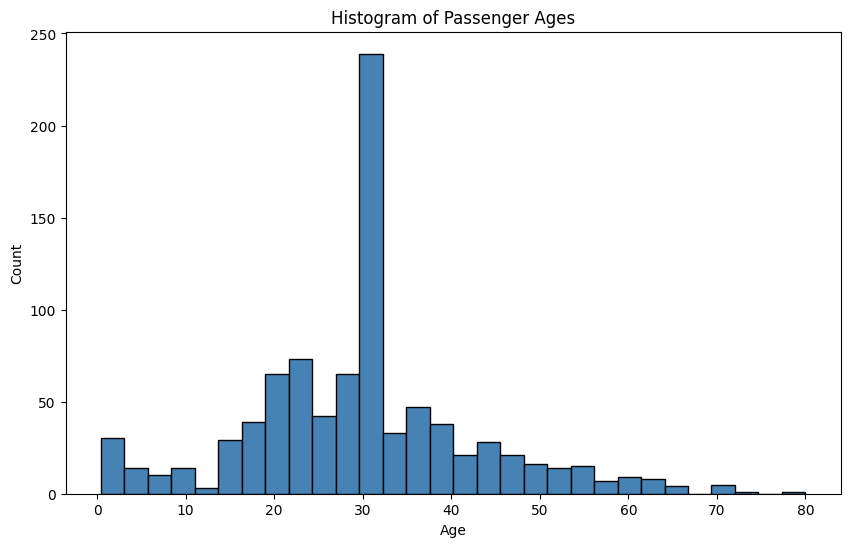

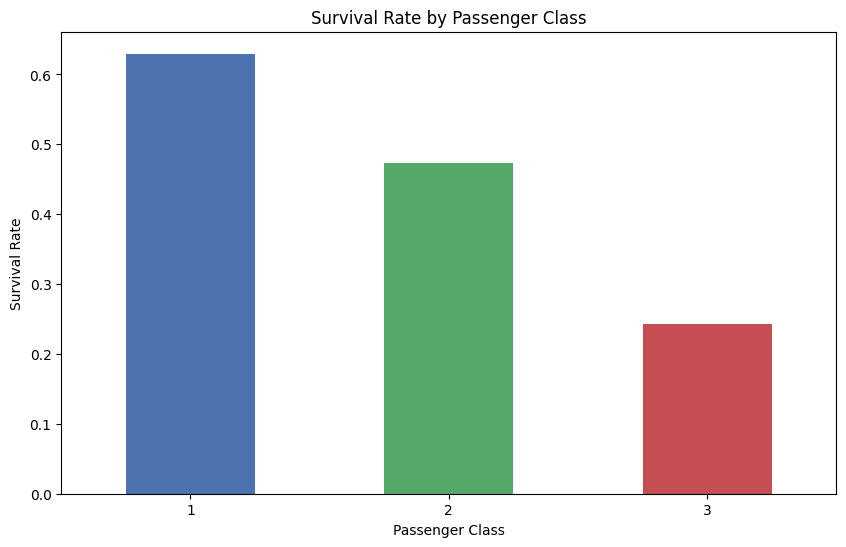

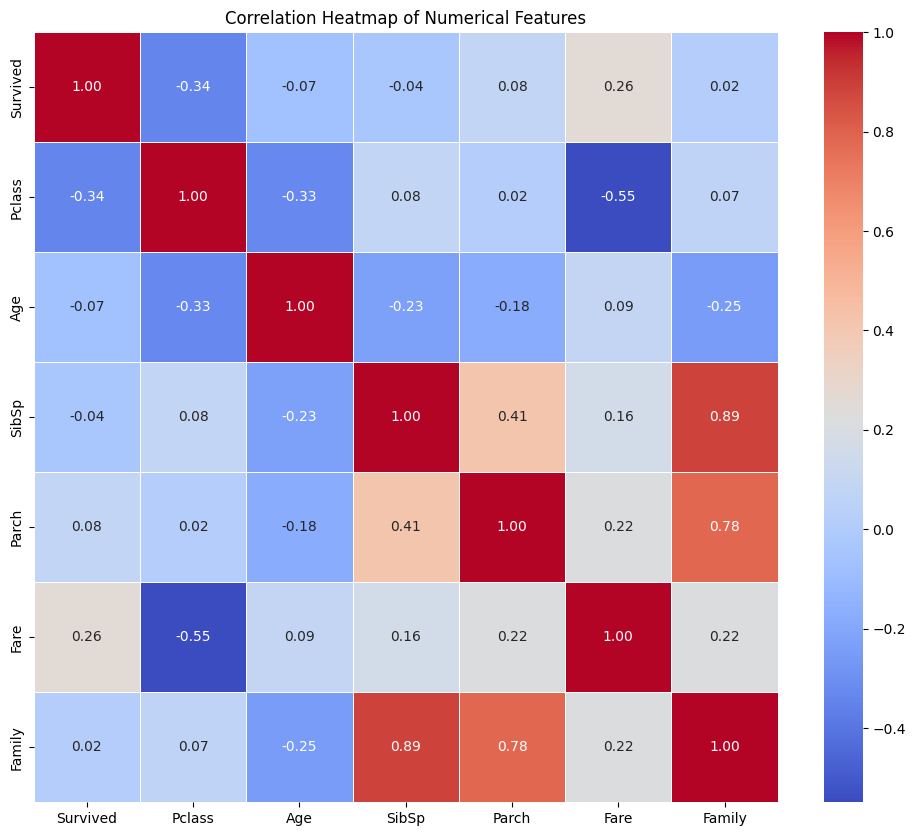

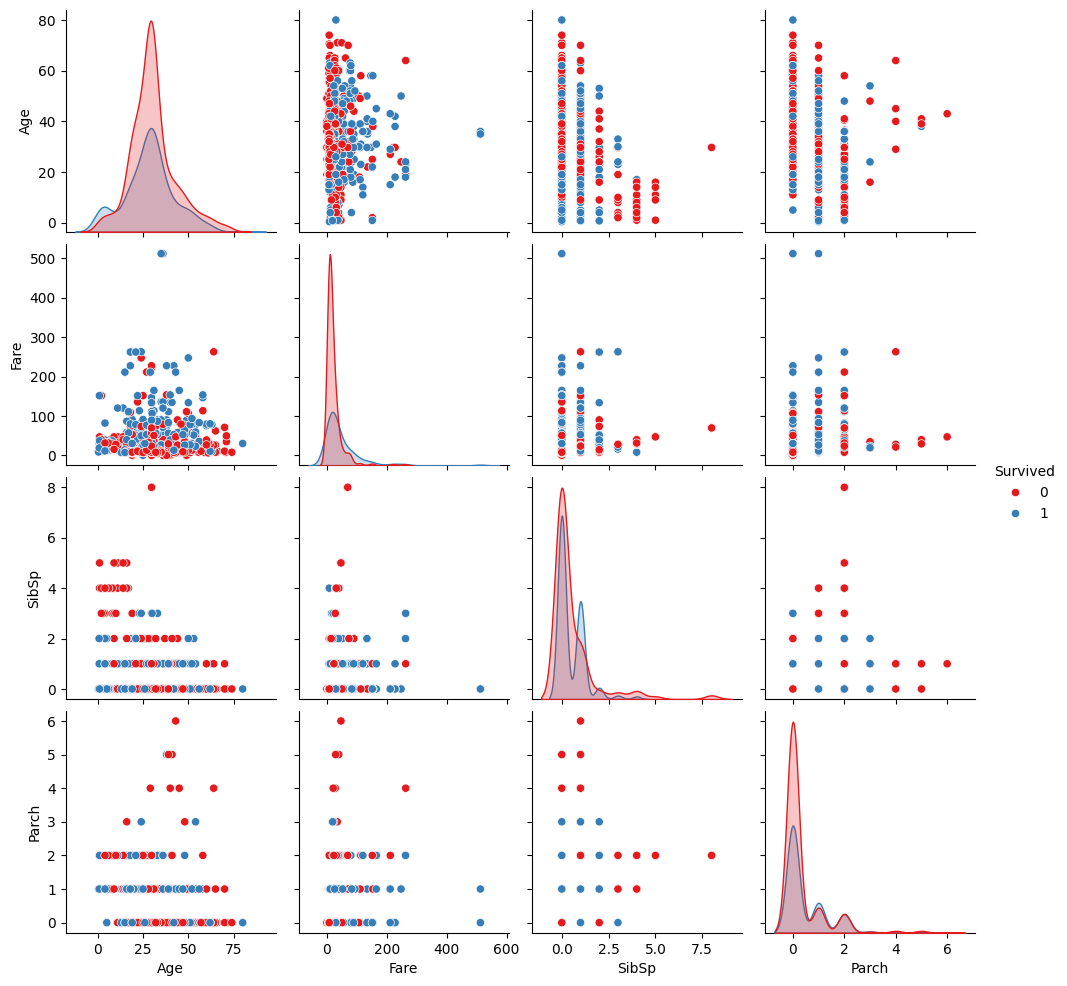

In [9]:
# Task 7: Visualizations

# TODO: Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# TODO: Create a bar plot of survival rates by passenger class
survival_by_class_plot = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(10, 6))
survival_by_class_plot.plot(kind='bar', color=['#4c72b0', '#55a868', '#c44e52'])
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

# TODO: Create a heatmap of correlation between numerical features
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
sns.pairplot(df, vars=['Age', 'Fare', 'SibSp', 'Parch'], hue='Survived', palette='Set1')
plt.show()



### Visualization Insights

- **Age histogram**: shows a roughly normal-ish spread, but with a visible spike around age 30 —
  this is an artifact of filling missing ages with the mean (29.7), not a natural pattern in the data.
- **Survival by class**: confirms 1st class passengers survived at the highest rate, dropping steadily
  through 2nd and 3rd class — consistent with the Sex/Pclass breakdown from Task 6.
- **Correlation heatmap**: `Fare` and `Pclass` show a strong negative correlation (higher fare = lower
  class number = 1st class), and `Survived` correlates positively with `Fare` and negatively with `Pclass`,
  reinforcing that wealthier, higher-class passengers were more likely to survive.
- **Pair plot**: survivors (orange/red, depending on palette) tend to cluster at higher fares, while
  non-survivors are more spread across lower fares — visually reinforcing the fare/survival relationship.

In [10]:
# Task 8: Analyze survival rates

# TODO: Calculate and display survival rates by sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("Survival rate by sex:")
print(survival_by_sex)

# TODO: Calculate and display survival rates by passenger class
survival_by_class = df.groupby('Pclass')['Survived'].mean()
print("\nSurvival rate by passenger class:")
print(survival_by_class)



Survival rate by sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


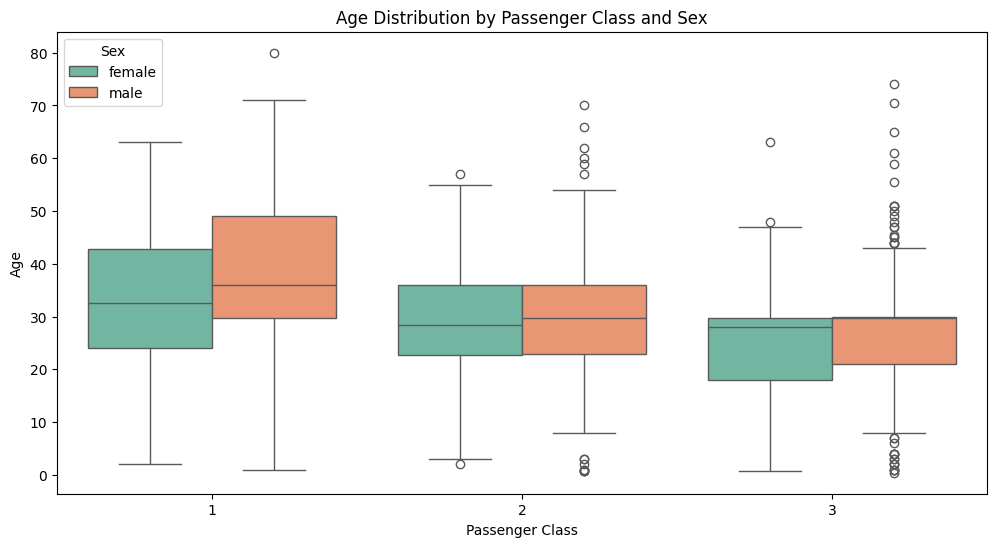

In [11]:
# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Pclass', y='Age', hue='Sex', palette='Set2')
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()



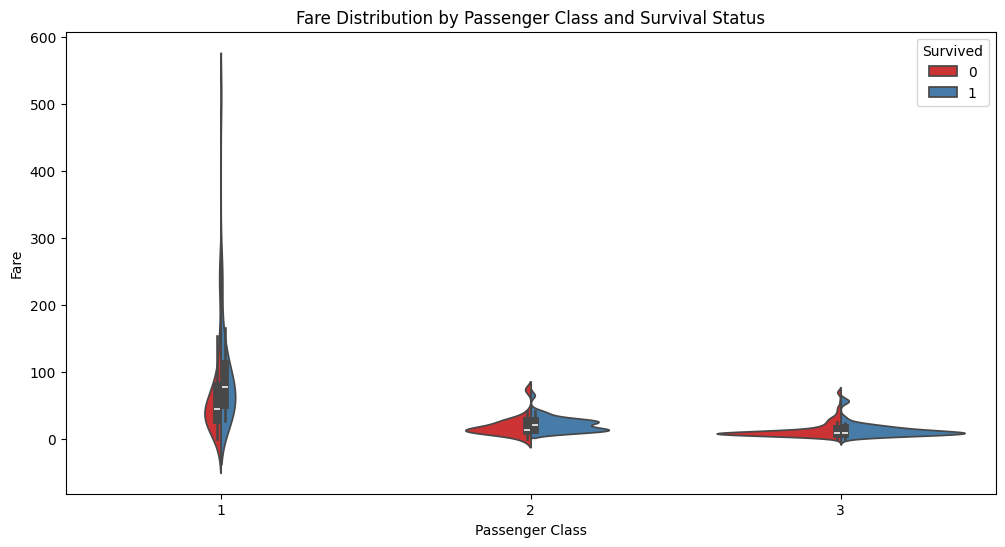

EDA tasks completed.


In [12]:
# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Pclass', y='Fare', hue='Survived', split=True, palette='Set1')
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

print("EDA tasks completed.")

## Overall EDA Summary — Titanic Dataset

**Data quality:**
- The dataset had two columns with significant missing data: `Age` (177 missing, ~20%) and
  `Cabin` (687 missing, ~77%). `Age` was imputed with the mean; `Cabin` was instead converted
  into a categorical deck feature with an explicit "Unknown" category, since imputing a cabin
  number wouldn't be meaningful.

**Key survival drivers:**
- **Sex** was the single strongest predictor of survival — women survived at ~74% versus ~19% for men,
  consistent with "women and children first" evacuation protocols.
- **Passenger class** was the second major factor — 1st class passengers survived at ~63%, compared to
  ~24% in 3rd class. This effect held within each sex group too (seen clearly in the Sex/Pclass
  multi-index breakdown).
- **Fare** correlates strongly with class and survival, reinforcing that wealthier passengers had
  meaningfully better odds, likely due to cabin location and lifeboat proximity.

**Family size:**
- Family size varied widely, with some very large families (up to 10 members) traveling together.
  Family size patterns are worth further investigation as a survival factor in follow-up analysis
  (e.g., very large families may have had *lower* survival odds due to difficulty staying together
  during evacuation).

**Limitations:**
- Mean imputation for `Age` introduces a slight artificial spike around age 30, which should be kept
  in mind when interpreting the age histogram and box plot.
- This analysis only covers correlation, not causation — e.g., `Fare`/`Pclass` correlating with survival
  doesn't prove wealth *caused* survival, only that it's strongly associated with it.

In [13]:
!git config --global user.name "conslcan"
!git config --global user.email "conslcan@gmail.com"
!git clone https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 27 (delta 10), reused 21 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 51.26 KiB | 1.97 MiB/s, done.
Resolving deltas: 100% (10/10), done.
